In [5]:
import torch
from torchvision.transforms.v2 import RandomHorizontalFlip as rhflip, RandomVerticalFlip as rvflip
import torch.nn as nn
import torch.nn.functional as F
from functools import partial
import matplotlib.pyplot as plt
import scipy.io as io
import sys
import numpy as np
from tqdm import tqdm
import gc

global_path = "/home/ids/edabier/HSU"
sys.path.append(f"{global_path}/HyperSIGMA/HyperspectralUnmixing")
sys.path.append(f"{global_path}/SS-HSU_benchmark")
from mmengine.optim import build_optim_wrapper
from mmcv__custom import custom_layer_decay_optimizer_constructor

from src.utils import utils, losses, plots, extractor
from src.models import models, upsamplers, foundation_models as rsfm, unmixers as unmx

dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_device(dev)
print(f"Using device: {dev}")

Using device: cuda


In [6]:
dataset = "samson"
data = io.loadmat(f"{global_path}/SS-HSU_benchmark/datasets/{dataset}.mat")
Y_flat = torch.tensor(data["Y"], dtype=torch.float)
A_flat = torch.tensor(data["A"], dtype=torch.float)
E_init = torch.tensor(data["E"], dtype=torch.float)
B, c, N = E_init.shape[0], E_init.shape[1], Y_flat.shape[1]

Y_init = utils.oneD_to_2d(Y_flat)
H = Y_init.shape[-1]
A_init = utils.oneD_to_2d(A_flat)
Y_init = Y_init.unsqueeze(0)
Y_init_n = utils.standardise(Y_init)
A_init = A_init.unsqueeze(0)

if dataset == "urban4":
    wavelengths_path = f"{global_path}/SS-HSU_benchmark/datasets/urban_wavelength.txt"
else:
    wavelengths_path = f"{global_path}/SS-HSU_benchmark/datasets/{dataset}_wavelength.txt"
with open(wavelengths_path, "r") as file:
    lines = file.readlines()
    wavelengths = [float(line.strip()) for line in lines if line.strip()]

Y_init_f = rsfm.reshape_Y("DOFA", Y_init, None)

features: torch.Size([1024, 196])


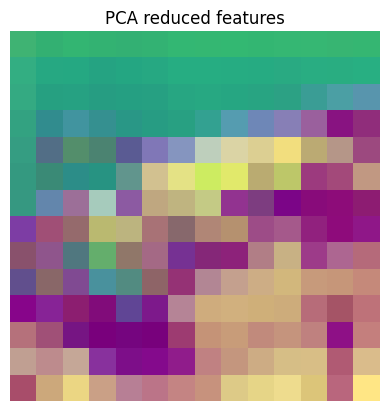

In [7]:
fm_name = "DOFA"
fm, Y_init_f, new_H = rsfm.create_fm(fm_name, Y_init, size="large", version="v1", path=global_path)

_, features = rsfm.extract_f(fm, Y_init, new_H, wavelengths)#, patch_size=112)

D = int(features.shape[0])
alpha = int(features.shape[1]**0.5)

print(f"features: {features.shape}")
plots.plot_pca_features(features)

training 1/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.229, NMSE = 0.211
training 2/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.225, NMSE = 0.205
training 3/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.221, NMSE = 0.201
training 4/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.244, NMSE = 0.203
training 5/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.233, NMSE = 0.206
training 6/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.223, NMSE = 0.205
training 7/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.235, NMSE = 0.205

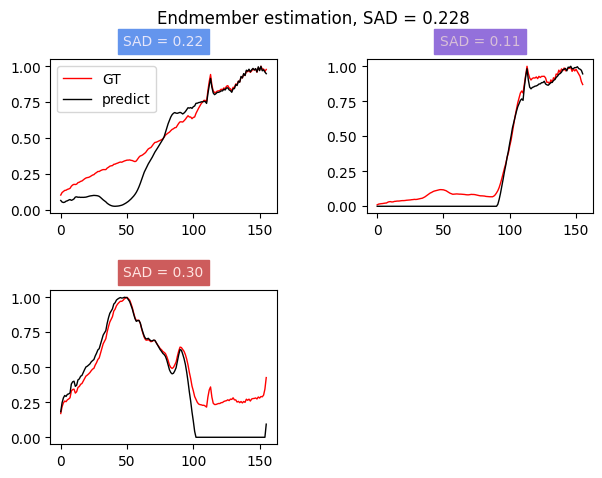

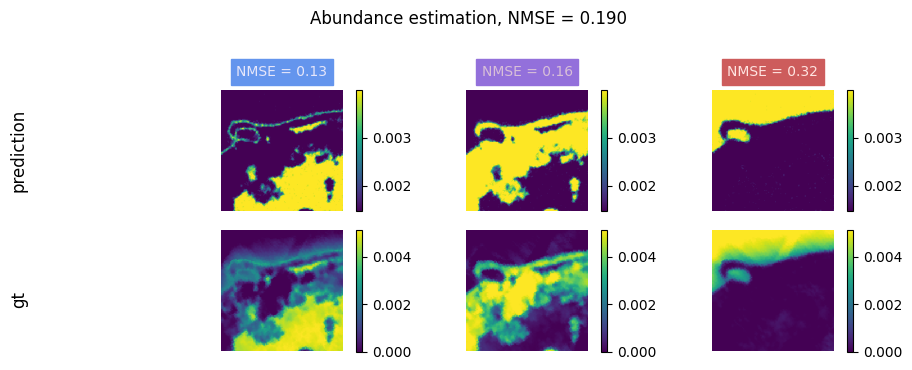

In [ ]:
"""Linear upsampling of feature"""

n_xp = 10
mses, sads = [], []
E_hats, A_hats = torch.zeros(n_xp, B, c), torch.zeros(n_xp, c, new_H, new_H)
loader, _, _ = utils.create_dataloader(dataset, patch_size=H, dev=dev, path=global_path)

for i in range(n_xp):
    print(f"training {i+1}/{n_xp}")

    model = unmx.UnmixingFromFeaturesTrans(D=D, alpha=alpha, H=new_H, B=B, c=c, patch_size=7, embed_dim=392)
    model.apply(model.weights_init)
    model = models.init_decoder_weights(model, Y_init_f/Y_init_f.max(), c, is_unmixer=True)

    epochs, lr = 200, 0.002
    optim_wrapper = dict(
        optimizer=dict(type='AdamW', lr=lr, betas=(0.9, 0.999), weight_decay=0.18),
        constructor='LayerDecayOptimizerConstructor_ViT',
        paramwise_cfg=dict(num_layers=12, layer_decay_rate=0.9, ))
    optimizer = build_optim_wrapper(model, optim_wrapper)

    for _ in range(epochs):

        for Y, _, _ in loader:
        
            optimizer.zero_grad()

            Y = utils.oneD_to_2d(Y).to(dev)

            _, features = rsfm.extract_f(fm, Y, new_H, wavelengths)
            Y_fm = rsfm.reshape_Y("DOFA", Y, new_H)

            E_hat, A_hat, Y_hat = model(features, Y_fm)

            loss = model.loss(Y_fm, Y_hat, A_hat, E_hat)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=10, norm_type=1)
            optimizer.step()
            
            with torch.no_grad():
                constraints = models.weightConstraint()
                model.decoder.apply(constraints)
    
    model.eval()
    
    with torch.no_grad():
        
        _, features = rsfm.extract_f(fm, Y, new_H, wavelengths)
        Y_fm, A_init_fm = rsfm.reshape_Y("DOFA", Y, new_H, A_init)
        E_hat, A_hat, _ = model(features, Y_fm)

        sad, _, mse = plots.compute_metrics_and_plot(E_hat, A_hat, A_init_fm, E_init, normalise_E=True, normalise_A=True, return_results=True, plot_E=False, plot_A=False)
        print(f"Current SAD = {format(sad, '.3f')}, NMSE = {format(mse, '.3f')}")
        mses.append(mse)
        sads.append(sad)

    E_hats[i] = E_hat
    A_hats[i] = A_hat.squeeze(0)

E_hat_m = torch.mean(E_hats, dim=0)
A_hat_m = torch.mean(A_hats, dim=0)
sad, _, mse = plots.compute_metrics_and_plot(E_hat_m, A_hat_m, A_init_fm, E_init, normalise_E=True, normalise_A=True, return_results=True)
print(f"Model has {sum(p.numel() for p in model.parameters() if p.requires_grad)/1e6}M params")
print(f"Average SAD = {format(torch.mean(torch.tensor(sads)), '.4f')} ± {format(torch.std(torch.tensor(sads)), '.3f')}, NMSE = {format(torch.mean(torch.tensor(mses)), '.4f')} ± {format(torch.std(torch.tensor(mses)), '.3f')}")